In [3]:
import matplotlib.pyplot as plt #Библиотека за визуелизација
import seaborn as sns
import numpy as np #Библиотека за нумерички анализи
import pandas as pd
from scipy import stats #Библиотека за статистички анализи
from sklearn.model_selection import train_test_split
from sklearn import datasets #Библиотека за податочни множества за машинско учење
from sklearn.preprocessing import MinMaxScaler #Min max Scaler за нормализација на податоци во опсег [0,1]
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge #Вчитување на модели за линерна регресија
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #За евалуација на модели
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.datasets import fetch_california_housing

In [4]:
data = pd.read_csv("diamonds.csv") # Вчитување на податочното множество

In [7]:
data

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [9]:
data.head(15)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [11]:
# Define X (features) and y (target) from your diamonds dataset
X = data[["carat", "depth", "table", "x", "y", "z"]].values  # Features: Carat, Depth, Table, X, Y, Z
y = data["price"].values  # Target: Price

# Number of features and targets
number_of_features = X.shape[1]  # Number of features (columns in X)
number_of_targets = 1  # Since price is a continuous variable, it's one target variable

# Feature names
feature_names = ["carat", "depth", "table", "x", "y", "z"]

# Target name
target_names = ["price"]

# Print information about the dataset
print("Имиња на излезните класи: ", target_names)
print("Број на карактеристики (атрибути): ", number_of_features)  # Number of attributes
print("Број на излезни класи: ", number_of_targets)  # Number of output variables
print("Број на инстанци: ", X.shape[0])  # Number of instances (rows in X)


Имиња на излезните класи:  ['price']
Број на карактеристики (атрибути):  6
Број на излезни класи:  1
Број на инстанци:  53940


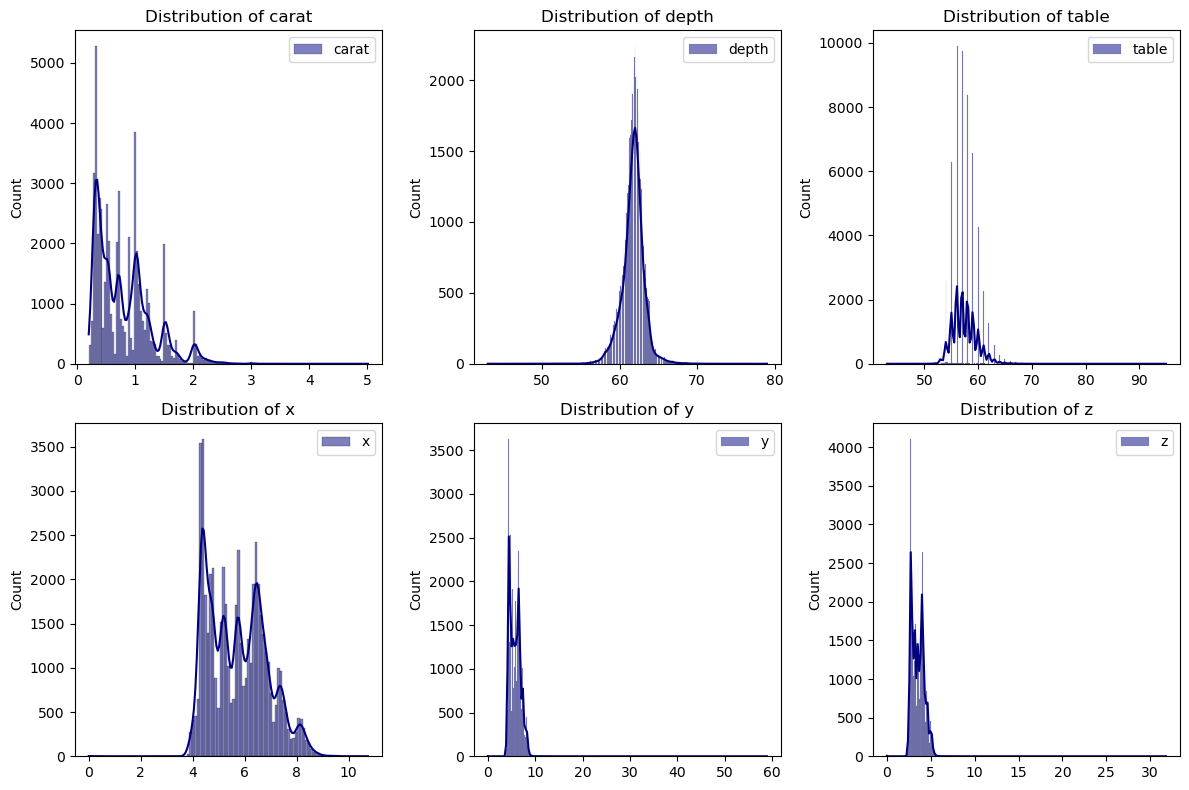

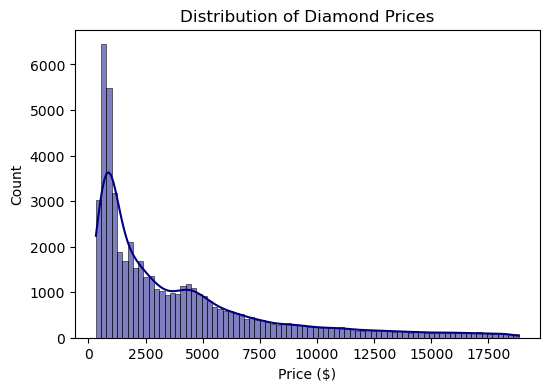

In [13]:
# Define features (X) and target (y)
features = ["carat", "depth", "table", "x", "y", "z"]  # Multiple features
X = data[features].values  # Extract all selected features
y = data["price"].values  # Target variable: Price
N = len(y)

# Histograms for multiple features
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))  # 2x3 grid for 6 features
axes = axes.ravel()  # Flatten axes array for easy iteration

for i, feat in enumerate(features):
    sns.histplot(X[:, i], color='navy', label=feat, kde=True, stat="count", ax=axes[i])
    axes[i].set_title(f"Distribution of {feat}")
    axes[i].legend()

plt.tight_layout()
plt.show()

# Histogram for target variable (Price)
fig = plt.figure(figsize=(6, 4))
sns.histplot(y, color="navy", kde=True)
plt.xlabel("Price ($)")
plt.title("Distribution of Diamond Prices")
plt.show()


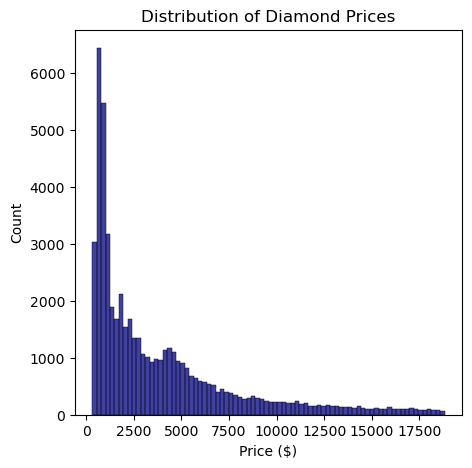

In [59]:
# Histogram for target variable (Price)
fig = plt.figure(figsize=(5, 5))  # Set the figure size to (5, 5)
sns.histplot(y, color="navy")  # Plot the histogram with navy color
plt.xlabel("Price ($)")  # Optional: Label for the x-axis
plt.title("Distribution of Diamond Prices")  # Optional: Title for the plot
plt.show()


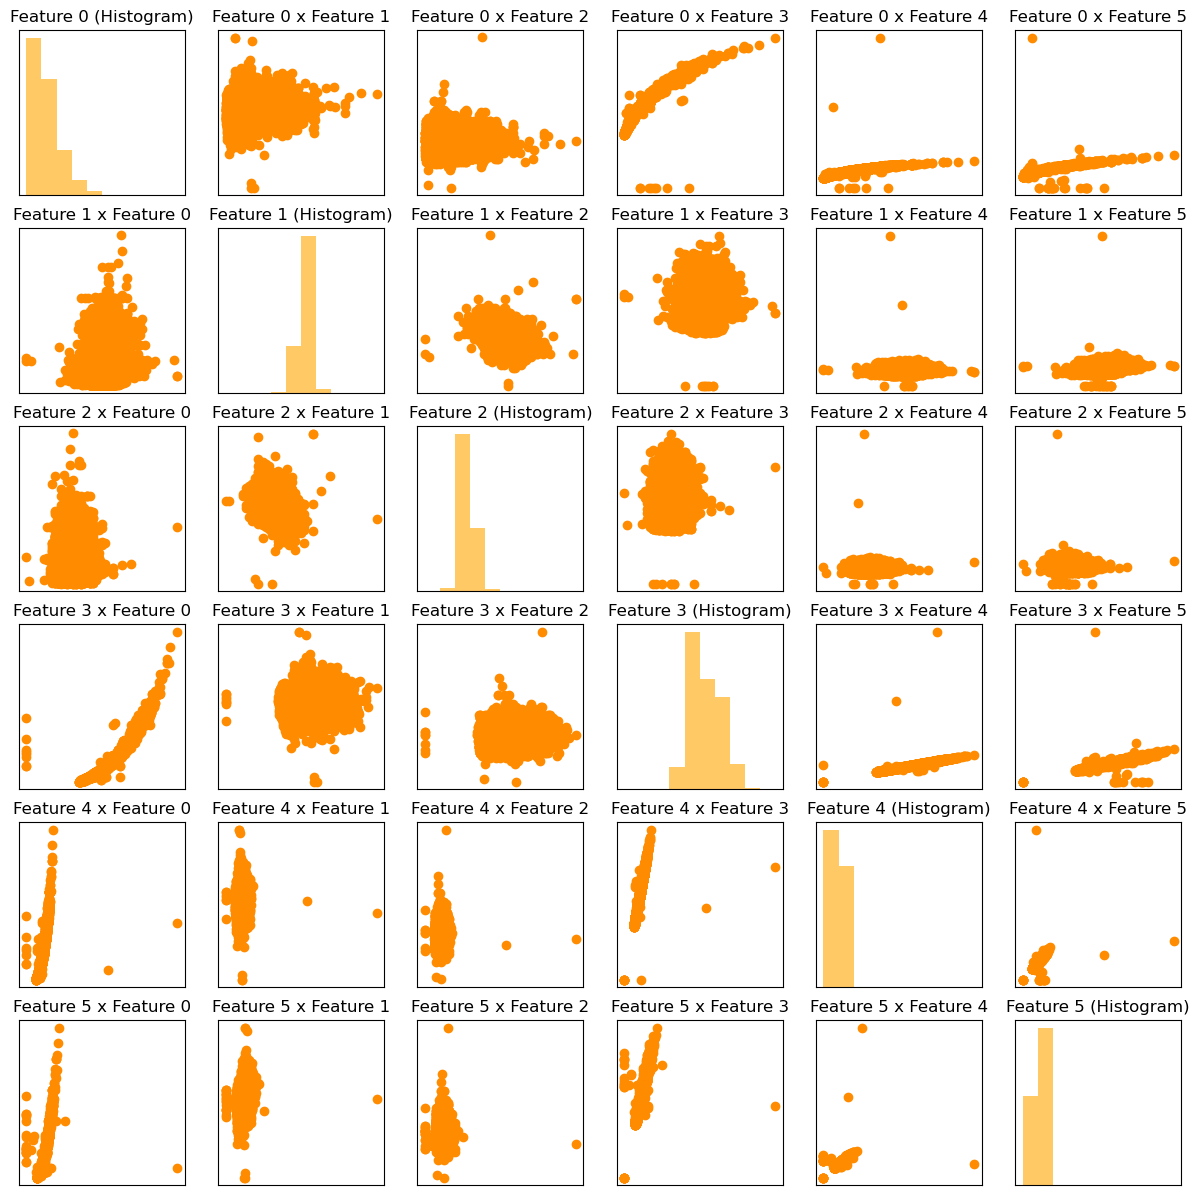

In [61]:
# Define features (X) and target (y)
features = ["carat", "depth", "table", "x", "y", "z"]  # Multiple features
X = data[features].values  # Extract all selected features
y = data["price"].values  # Target variable: Price

number_of_features = len(features)  # Number of features in your dataset

# Create a figure with a larger size (15x15)
fig = plt.figure(figsize=(15, 15))
fig.subplots(nrows=number_of_features, ncols=number_of_features)

# Loop through each pair of features
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        ax = plt.subplot(number_of_features, number_of_features, number_of_features * feature_i + feature_j + 1)
        
        # If it's the same feature (diagonal), plot a histogram
        if feature_i == feature_j:
            plt.hist(X[:, feature_i], alpha=0.6, color="orange")
            plt.title(f"Feature {feature_i} (Histogram)")
        else:
            # If it's a pair of different features, plot a scatter plot
            plt.scatter(X[:, feature_i], X[:, feature_j], color="darkorange")
            plt.title(f"Feature {feature_i} x Feature {feature_j}")  # Feature i x Feature j

        plt.xticks(())
        plt.yticks(())

# Show the plots
plt.show()


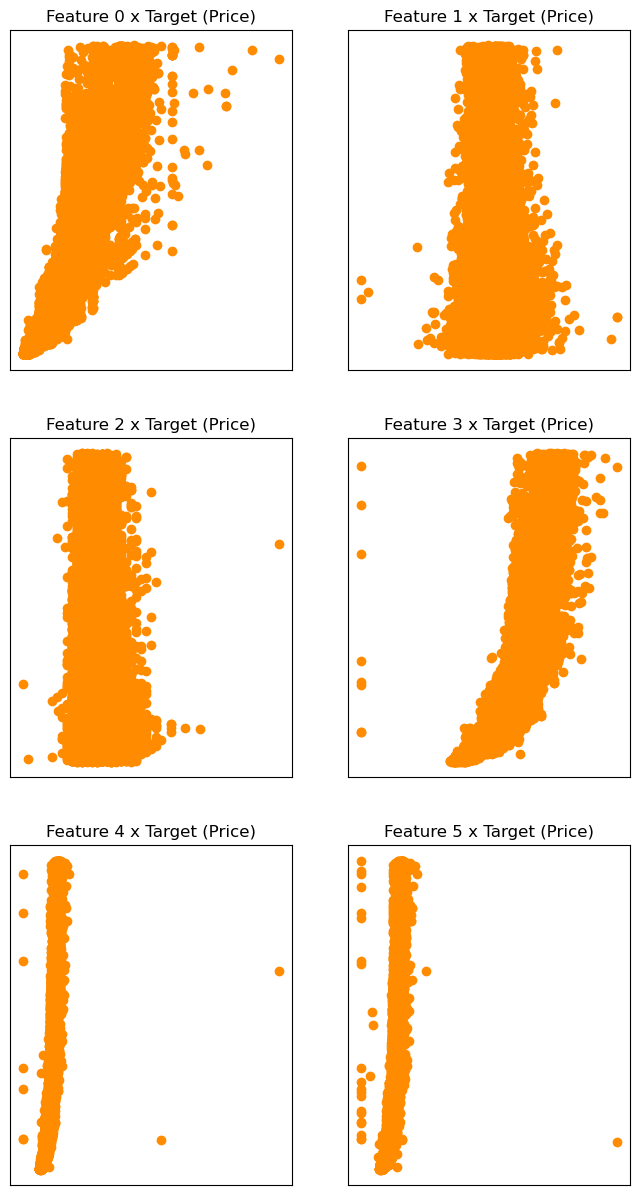

In [63]:
# Define features (X) and target (y)
features = ["carat", "depth", "table", "x", "y", "z"]  # Multiple features
X = data[features].values  # Extract all selected features
y = data["price"].values  # Target variable: Price

number_of_features = len(features)  # Number of features in your dataset

# Create a figure with a larger size (8x15)
fig = plt.figure(figsize=(8, 15))

# Create a 2-column layout, with as many rows as necessary
fig.subplots(nrows=(number_of_features // 2), ncols=2)

# Loop through each feature to plot against the target variable (price)
for feat_i in range(number_of_features):
    ax = plt.subplot((number_of_features // 2), 2, feat_i + 1)
    plt.scatter(X[:, feat_i], y, color="darkorange")  # Scatter plot of feature vs. price
    plt.xticks(())  # Remove x-ticks
    plt.yticks(())  # Remove y-ticks
    plt.title(f"Feature {feat_i} x Target (Price)")  # Title for each subplot

# Show the plots
plt.show()


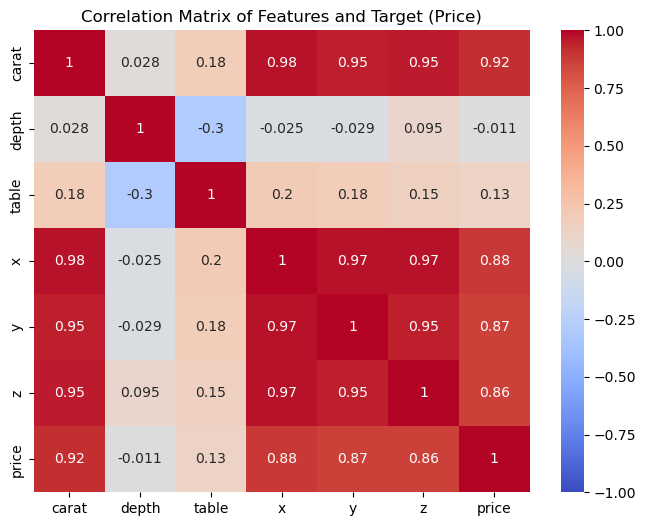

In [65]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Define features (X) and target (y)
features = ["carat", "depth", "table", "x", "y", "z"]  # Multiple features
X = data[features].values  # Extract all selected features
y = data["price"].values  # Target variable: Price
number_of_features = len(features)  # Number of features in your dataset

# Initialize the correlation matrix
correlation_matrix = np.zeros((number_of_features + 1, number_of_features + 1))

# Compute Pearson correlation coefficients for all pairs of features
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        corr, _ = stats.pearsonr(X[:, feature_i], X[:, feature_j])
        correlation_matrix[feature_i][feature_j] = corr

# Compute Pearson correlation coefficients for each feature with the target variable
for feature_i in range(number_of_features):
    target_i = number_of_features  # Target is placed at the last index in the matrix
    corr, _ = stats.pearsonr(X[:, feature_i], y)
    correlation_matrix[feature_i][target_i] = corr
    correlation_matrix[target_i][feature_i] = corr

# Compute the Pearson correlation coefficient for the target variable with itself (this will always be 1)
corr, _ = stats.pearsonr(y, y)
correlation_matrix[target_i][target_i] = corr

# Plot the correlation matrix using imshow
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, xticklabels=features + ["price"], yticklabels=features + ["price"])
plt.title("Correlation Matrix of Features and Target (Price)")
plt.show()


In [19]:
from sklearn.model_selection import cross_val_score


# Define features (X) and target (y)
features = ["carat", "depth", "table", "x", "y", "z"]  # Multiple features
X = data[features].values  # Extract all selected features
y = data["price"].values  # Target variable: Price

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Perform 5-fold cross-validation
reg = LinearRegression()  # Initialize the regression model
cv_scores = cross_val_score(reg, X, y, cv=5)  # 5-fold cross-validation

# Print the cross-validation scores and their average
print(f"Cross-validation scores: {cv_scores}")
print(f"Average cross-validation score: {np.mean(cv_scores)}")


Cross-validation scores: [-0.43788508  0.36764073  0.73302822 -3.26469605 -0.74091918]
Average cross-validation score: -0.6685662712902276


Коефициенти W:  [ 50970.14203549  -7206.54155653  -5380.36850927 -13366.19273317
   1905.11089466   1435.22854484]
Пресек W0:  9637.021822922197
Средна квадратна грешка: 2189040.813500751
Средна апсолутна грешка: 885.2691560939444
Корен на средна квадратна грешка: 1479.5407441164812
R-квадрат:  0.859640551634937


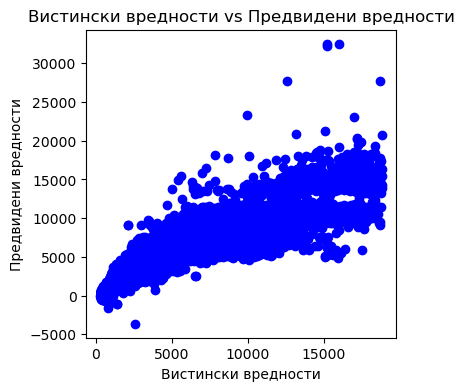

In [29]:

# Assuming 'data' is your dataset and the relevant columns are 'carat', 'depth', 'table', 'x', 'y', 'z', and 'price'

# Define features (X) and target (y)
features = ["carat", "depth", "table", "x", "y", "z"]  # Multiple features
X = data[features].values  # Extract all selected features
y = data["price"].values  # Target variable: Price

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Initialize and fit the linear regression model
reg = LinearRegression().fit(X_train, y_train)

# Print coefficients and intercept
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

# Predict the values for the test data
y_pred = reg.predict(X_test)

# Calculate and print error metrics
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred))  # Calculate R-squared value

# Visualization of predicted vs actual values
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Вистински вредности")  # Actual values
plt.ylabel("Предвидени вредности")  # Predicted values
plt.title("Вистински вредности vs Предвидени вредности")
plt.show()


Коефициенти W:  [47642.00772249 -6493.6411182  -5234.61748921 -9636.25742269
   263.08688982  -237.62756107]
Пресек W0:  7994.686115862223
Средна квадратна грешка: 2199040.0756137413
Средна апсолутна грешка: 903.5316369048768
Корен на средна квадратна грешка: 1482.916071668839
R-квадрат:  0.858999407392408


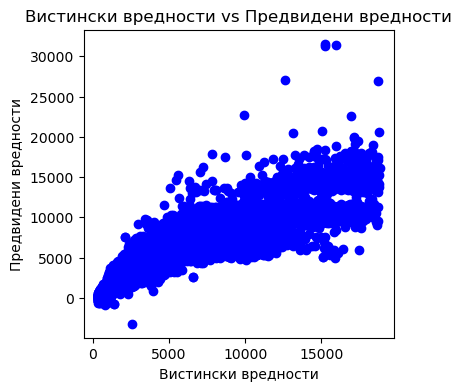

In [33]:
# Define features (X) and target (y)
features = ["carat", "depth", "table", "x", "y", "z"]  # Multiple features
X = data[features].values  # Extract all selected features
y = data["price"].values  # Target variable: Price

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Initialize and fit the Ridge regression model with regularization strength alpha=1
reg = Ridge(alpha=1).fit(X_train, y_train)

# Print coefficients and intercept
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

# Predict the values for the test data
y_pred = reg.predict(X_test)

# Calculate and print error metrics
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred))  # Calculate R-squared value

# Visualization of predicted vs actual values
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Вистински вредности")  # Actual values
plt.ylabel("Предвидени вредности")  # Predicted values
plt.title("Вистински вредности vs Предвидени вредности")
plt.show()

Коефициенти W:  [ 50525.85367393  -6968.83937317  -5308.09685871 -12310.03484696
      0.              0.        ]
Пресек W0:  9329.9866042941
Средна квадратна грешка: 2190362.199065419
Средна апсолутна грешка: 887.2165089491032
Корен на средна квадратна грешка: 1479.987229358895
R-квадрат:  0.8595558255084115


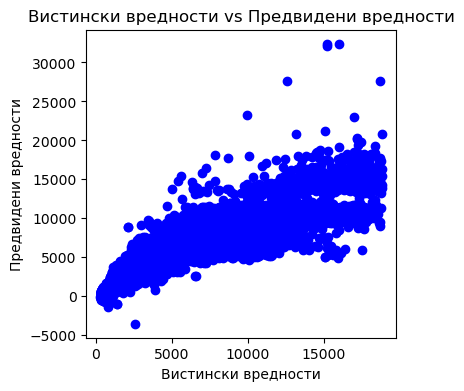

In [37]:

# Define features (X) and target (y)
features = ["carat", "depth", "table", "x", "y", "z"]  # Multiple features
X = data[features].values  # Extract all selected features
y = data["price"].values  # Target variable: Price

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Initialize and fit the Lasso regression model with regularization strength alpha=0.1
reg = Lasso(alpha=0.1).fit(X_train, y_train)

# Print coefficients and intercept
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

# Predict the values for the test data
y_pred = reg.predict(X_test)

# Calculate and print error metrics
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred))  # Calculate R-squared value

# Visualization of predicted vs actual values
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Вистински вредности")  # Actual values
plt.ylabel("Предвидени вредности")  # Predicted values
plt.title("Вистински вредности vs Предвидени вредности")
plt.show()

Коефициенти W:  [4026.51765644  -10.84611185  198.2144234  4032.85812588  733.15983189
  834.32410101]
Пресек W0:  1081.98003872984
Средна квадратна грешка: 10275964.121482026
Средна апсолутна грешка: 2367.6496664607994
Корен на средна квадратна грешка: 3205.6144686287566
R-квадрат:  0.3411138583552492


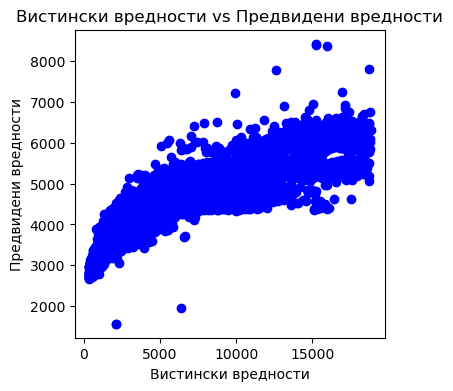

In [41]:
# Define features (X) and target (y)
features = ["carat", "depth", "table", "x", "y", "z"]  # Multiple features
X = data[features].values  # Extract all selected features
y = data["price"].values  # Target variable: Price

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Initialize and fit the ElasticNet regression model with alpha=0.1 and l1_ratio=0.3
reg = ElasticNet(alpha=0.1, l1_ratio=0.3).fit(X_train, y_train)

# Print coefficients and intercept
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

# Predict the values for the test data
y_pred = reg.predict(X_test)

# Calculate and print error metrics
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred))  # Calculate R-squared value

# Visualization of predicted vs actual values
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Вистински вредности")  # Actual values
plt.ylabel("Предвидени вредности")  # Predicted values
plt.title("Вистински вредности vs Предвидени вредности")
plt.show()

Коефициенти W:  [ 50952.61770091  -7202.28372015  -5379.71698642 -13342.72008436
   1885.25107223   1417.89269406]
Пресек W0:  9628.13934552957
Средна квадратна грешка: 2189070.4459787644
Средна апсолутна грешка: 885.3559860078526
Стандардна девијација на предвидените вредности: [1518.28120298 1519.44243712 1519.43019911 ... 1519.90804101 1519.84691968
 1518.87250732]
Број на предвидени вредности: 16182
Корен на средна квадратна грешка: 1479.550758162343
R-квадрат:  0.8596386516254707


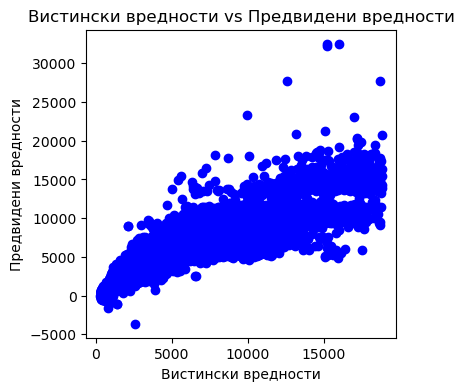

In [43]:
# Define features (X) and target (y)
features = ["carat", "depth", "table", "x", "y", "z"]  # Multiple features
X = data[features].values  # Extract all selected features
y = data["price"].values  # Target variable: Price

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Initialize and fit the BayesianRidge regression model
reg = BayesianRidge().fit(X_train, y_train)

# Print coefficients and intercept
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

# Predict the values for the test data and also return the standard deviation (uncertainty)
y_pred, y_std = reg.predict(X_test, return_std=True)

# Print error metrics and uncertainty
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Стандардна девијација на предвидените вредности:", y_std)  # Standard deviation
print("Број на предвидени вредности:", len(y_std))  # Length of the predicted standard deviation
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred))  # Calculate R-squared value

# Visualization of predicted vs actual values
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Вистински вредности")  # Actual values
plt.ylabel("Предвидени вредности")  # Predicted values
plt.title("Вистински вредности vs Предвидени вредности")
plt.show()

In [45]:


# Define Xi as the first feature (carat in your dataset)
Xi = X[:, 0].reshape(-1, 1)  # Extract the first feature (e.g., "carat")
N = len(y)  # Number of data points
print("Xi =", Xi)
print("y =", y)

# Initialize models
lr = LinearRegression()  # Linear Regression model
ridge = Ridge(alpha=1)  # Ridge Regression model with alpha=1
lasso = Lasso(alpha=0.1)  # Lasso Regression model with alpha=0.1
elastic = ElasticNet(alpha=0.1, l1_ratio=0.4)  # ElasticNet with alpha=0.1 and l1_ratio=0.4
Bayes = BayesianRidge()  # Bayesian Ridge Regression model

# Train the models
lr.fit(Xi, y)  # Linear regression model
ridge.fit(Xi, y)  # Ridge regression model
lasso.fit(Xi, y)  # Lasso regression model
elastic.fit(Xi, y)  # ElasticNet regression model
Bayes.fit(Xi, y)  # Bayesian Ridge regression model

# Calculate variances (sigma)
lrsigma = np.sum((y - lr.predict(Xi))**2) / (N - 2)
ridgesigma = np.sum((y - ridge.predict(Xi))**2) / (N - 2)
lassosigma = np.sum((y - lasso.predict(Xi))**2) / (N - 2)
elasticsigma = np.sum((y - elastic.predict(Xi))**2) / (N - 2)

# Print model coefficients
print("\nКоефициенти на моделите:")
print("Линеарна регресија: ", lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Регресија на еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

# Print variances (sigma values)
print("\nВаријанси на моделите:")
print(f"Линеарна регресија варијанса: {lrsigma}")
print(f"Риџ регресија варијанса: {ridgesigma}")
print(f"Ласо регресија варијанса: {lassosigma}")
print(f"Еластична мрежа варијанса: {elasticsigma}")


Xi = [[0.00623701]
 [0.002079  ]
 [0.00623701]
 ...
 [0.1039501 ]
 [0.13721414]
 [0.11434511]]
y = [ 326  326  327 ... 2757 2757 2757]

Коефициенти на моделите:
Линеарна регресија:  [37308.40722243]
Риџ регресија:  [37237.32051536]
Ласо регресија:  [37298.10998051]
Регресија на еластична мрежа: [5196.78108619]
Баесова риџ регресија:  [37308.28451998]

Варијанси на моделите:
Линеарна регресија варијанса: 2398043.965250546
Риџ регресија варијанса: 2398093.0415695673
Ласо регресија варијанса: 2398044.9950129194
Еластична мрежа варијанса: 12412325.223269537


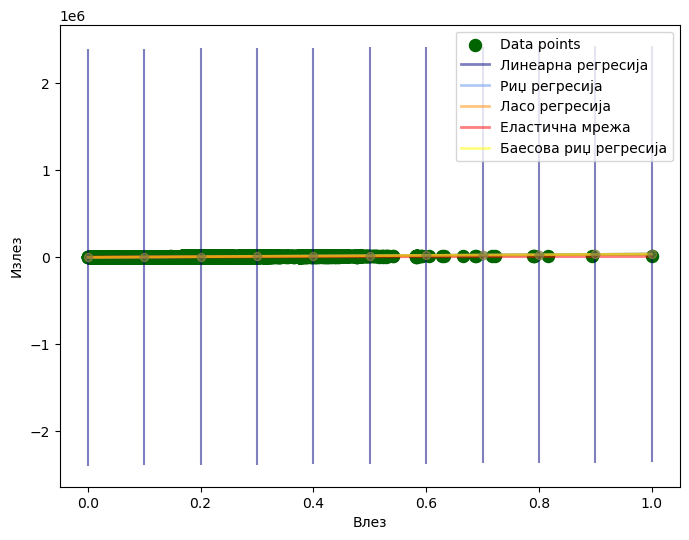

In [53]:

# Define line_X as the range of values for the predictions
line_X = np.arange(0, 1.1, 0.1)[:, np.newaxis]  # Range [0, X.max()]
line_y = lr.predict(line_X)  # Linear regression predictions
line_y_ridge = ridge.predict(line_X)  # Ridge regression predictions
line_y_lasso = lasso.predict(line_X)  # Lasso regression predictions
line_y_elastic = elastic.predict(line_X)  # ElasticNet predictions
line_y_bayes, Bayessigma = Bayes.predict(line_X, return_std=True)  # Bayesian Ridge regression predictions with standard deviation

# Line width for plot visualization
lw = 2

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the data points
plt.scatter(Xi, y, color='darkgreen', marker='.', s=300, label='Data points')

# Plot the regression lines for each model
plt.plot(line_X, line_y, color='navy', linewidth=lw, label='Линеарна регресија', alpha=0.5)
plt.errorbar(line_X, line_y, yerr=lrsigma, fmt='o', color='navy', alpha=0.5)

plt.plot(line_X, line_y_ridge, color='cornflowerblue', linewidth=lw, label='Риџ регресија', alpha=0.5)
plt.plot(line_X, line_y_lasso, color='darkorange', linewidth=lw, label='Ласо регресија', alpha=0.5)
plt.plot(line_X, line_y_elastic, color='red', linewidth=lw, label='Еластична мрежа', alpha=0.5)

plt.plot(line_X, line_y_bayes, color='yellow', linewidth=lw, label='Баесова риџ регресија', alpha=0.5)
plt.errorbar(line_X, line_y_bayes, yerr=Bayessigma, fmt='o', color='yellow', alpha=0.3)

# Add labels and legend
plt.legend(loc='best')
plt.xlabel("Влез")
plt.ylabel("Излез")

# Show the plot
plt.show()


Shape of Xi: (5,)
Shape of Xt: (5, 2)
Shape of y: (5,)
Coefficients of models:
Linear Regression: [0.80714286 0.10714286]
Ridge Regression: [0.24285714 0.19714286]
Lasso Regression: [0.         0.23529412]
ElasticNet Regression: [0.21373845 0.20164492]
Bayesian Ridge Regression: [0.45550253 0.16342176]


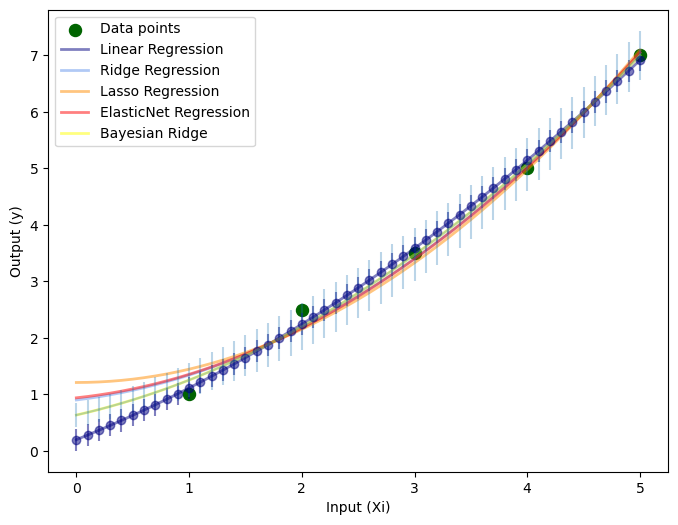

In [55]:

# Example data (you can replace this with your actual data)
Xi = np.array([1, 2, 3, 4, 5])  # Example input feature
y = np.array([1, 2.5, 3.5, 5, 7])  # Example target variable

# Polynomial expansion (Xi^1 and Xi^2)
p = np.array([1, 2])  # First power (Xi) and second power (Xi^2)
Xt = Xi[:, np.newaxis] ** p  # Xt will now have Xi and Xi^2 as features

# Check the shapes
print("Shape of Xi:", Xi.shape)
print("Shape of Xt:", Xt.shape)
print("Shape of y:", y.shape)

# Initialize models
lr = LinearRegression()
ridge = Ridge(alpha=1)
lasso = Lasso(alpha=0.1)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.4)
Bayes = BayesianRidge()

# Fit models to the data
lr.fit(Xt, y)
ridge.fit(Xt, y)
lasso.fit(Xt, y)
elastic.fit(Xt, y)
Bayes.fit(Xt, y)

# Calculate model errors (variance)
N = len(y)
lrsigma = np.sqrt(np.sum((y - lr.predict(Xt))**2) / (N - 2))
ridgesigma = np.sqrt(np.sum((y - ridge.predict(Xt))**2) / (N - 2))
lassosigma = np.sqrt(np.sum((y - lasso.predict(Xt))**2) / (N - 2))
elasticsigma = np.sqrt(np.sum((y - elastic.predict(Xt))**2) / (N - 2))
Bayessigma = np.sqrt(np.sum((y - Bayes.predict(Xt))**2) / (N - 2))

# Print model coefficients
print("Coefficients of models:")
print("Linear Regression:", lr.coef_)
print("Ridge Regression:", ridge.coef_)
print("Lasso Regression:", lasso.coef_)
print("ElasticNet Regression:", elastic.coef_)
print("Bayesian Ridge Regression:", Bayes.coef_)

# Generate predictions for plotting
line_X0 = np.arange(0, 5.1, 0.1)[:, np.newaxis]  # Line for plotting, range from 0 to 5
line_X1 = line_X0 ** 2  # Xi^2 for polynomial
line_X = np.concatenate((line_X0, line_X1), axis=1)  # Concatenate Xi and Xi^2

line_y = lr.predict(line_X)
line_y_ridge = ridge.predict(line_X)
line_y_lasso = lasso.predict(line_X)
line_y_elastic = elastic.predict(line_X)
line_y_bayes, Bayessigma = Bayes.predict(line_X, return_std=True)

# Set up error bars for Linear and Bayesian Ridge models
M = line_X1.size
lrsigma_array = np.ones(M) * lrsigma  # Create a constant array for error bars

# Visualization parameters
lw = 2  # Line width for plot
plt.figure(figsize=(8, 6))

# Plot the data points and the regression lines for each model
plt.scatter(Xi, y, color='darkgreen', marker='.', s=300, label='Data points')
plt.plot(line_X0, line_y, color='navy', linewidth=lw, label='Linear Regression', alpha=0.5)
plt.errorbar(line_X0.flatten(), line_y.flatten(), yerr=lrsigma_array, fmt='o', color='navy', alpha=0.5)

plt.plot(line_X0, line_y_ridge, color='cornflowerblue', linewidth=lw, label='Ridge Regression', alpha=0.5)
plt.plot(line_X0, line_y_lasso, color='darkorange', linewidth=lw, label='Lasso Regression', alpha=0.5)
plt.plot(line_X0, line_y_elastic, color='red', linewidth=lw, label='ElasticNet Regression', alpha=0.5)
plt.plot(line_X0, line_y_bayes, color='yellow', linewidth=lw, label='Bayesian Ridge', alpha=0.5)
plt.errorbar(line_X0.flatten(), line_y_bayes.flatten(), yerr=Bayessigma, alpha=0.3)

# Add legend, labels, and show the plot
plt.legend(loc='best')
plt.xlabel("Input (Xi)")
plt.ylabel("Output (y)")
plt.show()


In [57]:

# Apply SelectKBest to select the top 5 features based on the f_regression scoring function
selector = SelectKBest(f_regression, k=5)

# Fit the selector to the training data and transform X_train
X_train_new = selector.fit_transform(X_train, y_train)

# Transform the test data based on the fitted selector
X_test_new = selector.transform(X_test)

# Print the selected features (1 means selected, 0 means not selected)
print("Selected features:", selector.get_support().astype(int))

# Print the shape of the new transformed X_train (after feature selection)
print("Shape of X_train after feature selection:", X_train_new.shape)

# Print the shape of the transformed X_test (after feature selection)
print("Shape of X_test after feature selection:", X_test_new.shape)


Selected features: [1 0 1 1 1 1]
Shape of X_train after feature selection: (37758, 5)
Shape of X_test after feature selection: (16182, 5)


Средна квадратна грешка (ново): 2245630.448291138
Средна апсолутна грешка (ново): 904.4382849246223
Корен на средна квадратна грешка (ново): 1498.5427749287433
R-квадрат (ново):  0.8560120720408737


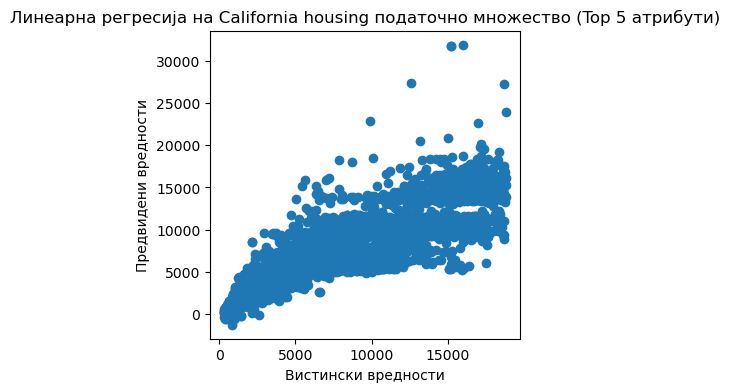

In [59]:
# Initialize the Linear Regression model
reg_new = LinearRegression()

# Fit the model on the selected features from X_train_new
reg_new.fit(X_train_new, y_train)

# Predict the target values using the model on the test set
y_pred_new = reg_new.predict(X_test_new)

# Print the performance metrics for the model using the selected features
print("Средна квадратна грешка (ново):", mean_squared_error(y_test, y_pred_new))
print("Средна апсолутна грешка (ново):", mean_absolute_error(y_test, y_pred_new))
print("Корен на средна квадратна грешка (ново):", np.sqrt(mean_squared_error(y_test, y_pred_new)))
print("R-квадрат (ново): ", r2_score(y_test, y_pred_new))  # Compute R-squared value

# Visualize the predicted values versus the actual values
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred_new)
plt.xlabel("Вистински вредности")  # Actual values
plt.ylabel("Предвидени вредности")  # Predicted values
plt.title("Линеарна регресија на California housing податочно множество (Top 5 атрибути)")
plt.show()
